/Users/lasseleekrogshave/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5
Epoch 1/50


/Users/lasseleekrogshave/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5871 - loss: 1.1371 - val_accuracy: 0.8575 - val_loss: 0.3879
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.8627 - loss: 0.3614 - val_accuracy: 0.9155 - val_loss: 0.2507
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - accuracy: 0.9151 - loss: 0.2285 - val_accuracy: 0.9469 - val_loss: 0.1925
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.9521 - loss: 0.1633 - val_accuracy: 0.9469 - val_loss: 0.1576
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - accuracy: 0.9565 - loss: 0.1394 - val_accuracy: 0.9541 - val_loss: 0.1499
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.9644 - loss: 0.1147 - val_accuracy: 0.9517 - val_loss: 0.1376
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - accuracy: 0.9588 - loss: 0.1066 - val_accuracy: 0.9614 - val_loss: 0.1272
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - accuracy: 0.9752 - loss: 0.0724 - val_accuracy: 0.9541 - val_lo

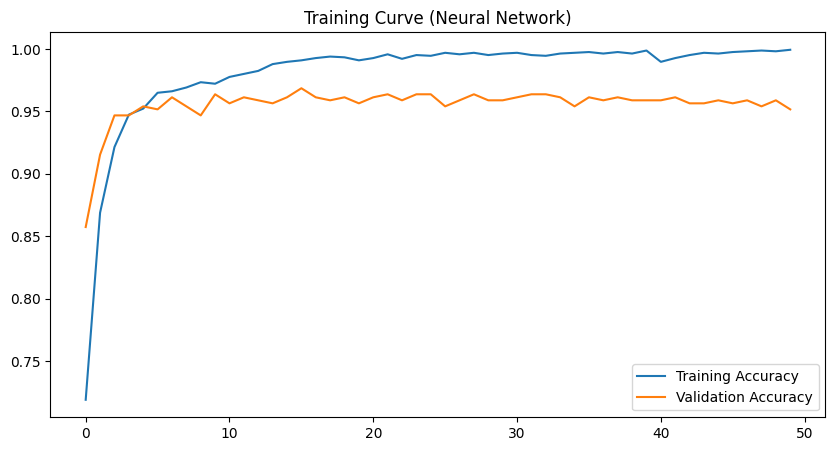

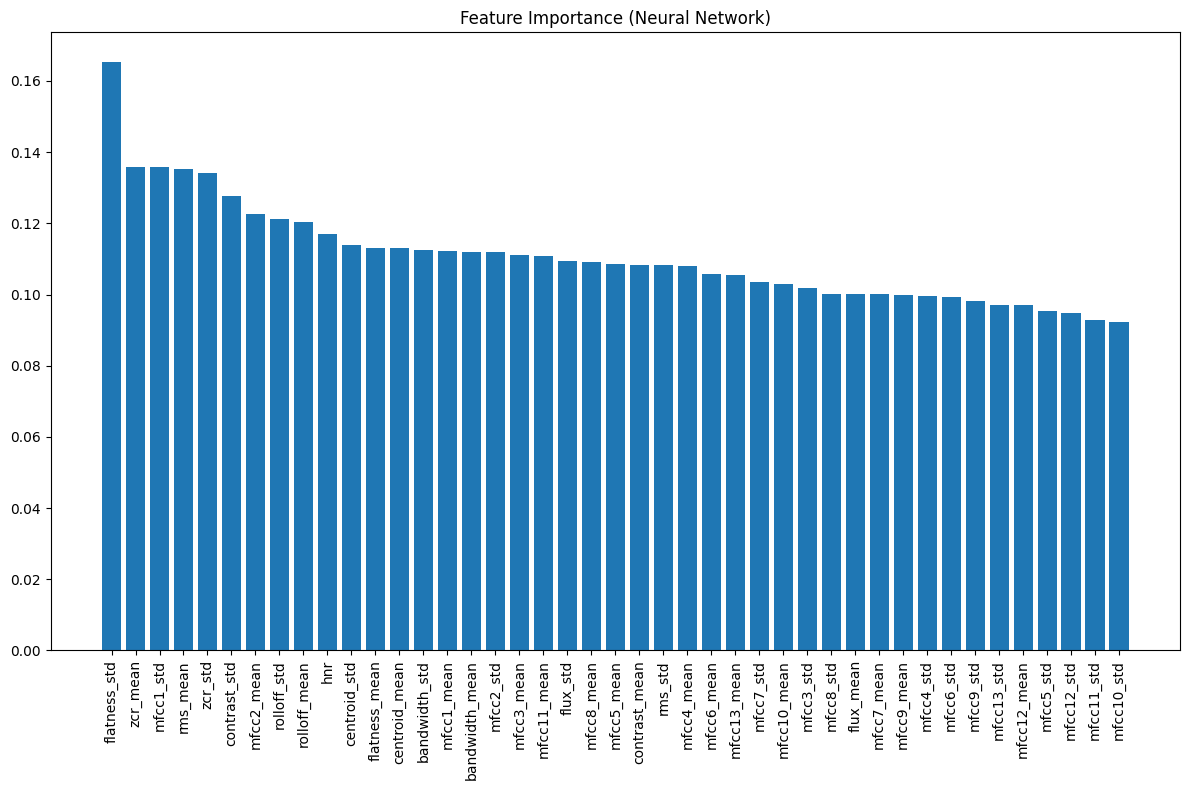


Top 15 vigtigste features:
flatness_std: 0.1654
zcr_mean: 0.1359
mfcc1_std: 0.1357
rms_mean: 0.1353
zcr_std: 0.1342
contrast_std: 0.1276
mfcc2_mean: 0.1226
rolloff_std: 0.1213
rolloff_mean: 0.1203
hnr: 0.1169
centroid_std: 0.1140
flatness_mean: 0.1132
centroid_mean: 0.1131
bandwidth_std: 0.1126
mfcc1_mean: 0.1121


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    tf = importlib.import_module("tensorflow")
    keras_api = tf.keras
except ImportError:
    keras_api = importlib.import_module("keras")

Sequential = keras_api.Sequential
Dense = keras_api.layers.Dense
Adam = keras_api.optimizers.Adam

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features fra training
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Klasse mapping:")
for i, class_name in enumerate(class_names):
    print(f"{class_name} -> {i}")

# Skalering (vigtigt for neural network)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. NEURAL NETWORK MODEL
# ----------------------------
input_dim = X_train.shape[1]
num_classes = len(class_names)

model = Sequential()
model.add(Dense(128, input_dim=input_dim, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------
# 5. VALIDATION TRAINING
# ----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=class_names))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. LOAD TEST DATA
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# Fjern kun filnavn (behold beta og snr til error analysis)
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Features til modellen (fjern kun target, beta, snr)
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")
y_test_true = label_encoder.transform(df_test["target"])
X_test_scaled = scaler.transform(X_test)

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# ----------------------------
# 7. TEST EVALUATION
# ----------------------------
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)

print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training Curve (Neural Network)")
plt.legend()
plt.show()

# ----------------------------
# 8. FEATURE IMPORTANCE
# ----------------------------
feature_names = X.columns

# Brug gennemsnitlig absolut vægt i første layer som feature-importance
first_layer_weights = model.layers[0].get_weights()[0]
importances = np.mean(np.abs(first_layer_weights), axis=1)

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (Neural Network)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54820/3145977978.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


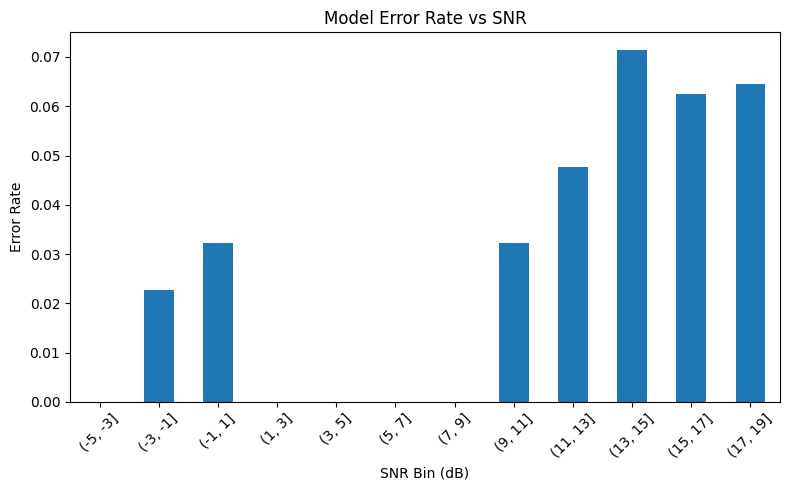

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54820/3145977978.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


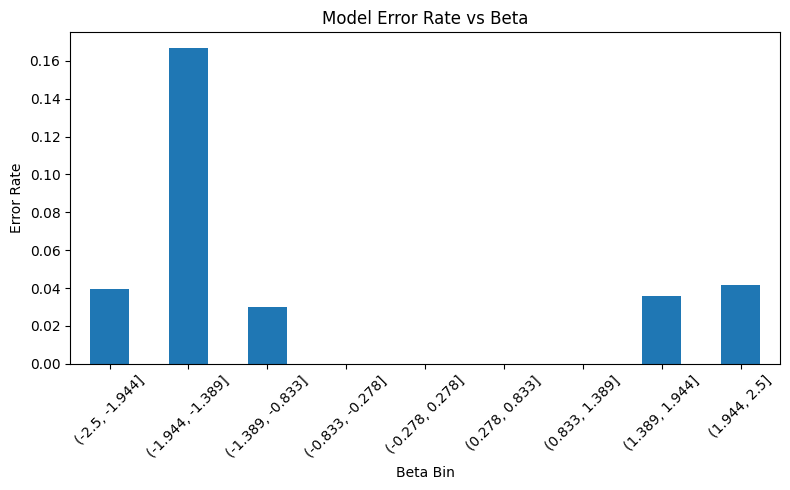


Eksempler på fejl:
      true_label   pred_label  beta  snr_db
27     BlueNoise        Clean -0.95   18.41
48     BlueNoise   WhiteNoise -1.00   13.48
76     BlueNoise  VioletNoise -1.05   16.49
115   BrownNoise        Clean  1.93   15.67
143   BrownNoise        Clean  1.97   19.00
172   BrownNoise        Clean  2.04   19.85
176   BrownNoise        Clean  2.05   14.09
200        Clean   BrownNoise   NaN     NaN
206        Clean  VioletNoise   NaN     NaN
218        Clean   BrownNoise   NaN     NaN
225        Clean    PinkNoise   NaN     NaN
234        Clean   BrownNoise   NaN     NaN
245        Clean    BlueNoise   NaN     NaN
284        Clean   BrownNoise   NaN     NaN
401  VioletNoise    BlueNoise -1.90   12.76
403  VioletNoise    BlueNoise -1.91   -0.45
410  VioletNoise    BlueNoise -1.93   -2.33
412  VioletNoise    BlueNoise -1.93   10.48
456  VioletNoise    BlueNoise -2.00   13.03
467  VioletNoise        Clean -2.02   16.31


In [ ]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# Gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# ----------------------------
# Fejlrate vs SNR
# ----------------------------
# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()

snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

# Beregn fejlrate pr SNR-bin
snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("Simple Neural Network Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------
# Fejlrate vs Beta
# ----------------------------
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("Simple Neural Network Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------
# Eksempler på fejl
# ----------------------------
df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))